In [1]:
!pip install ccxt==4.3.90 --force-reinstall --no-cache-dir -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 118.3/118.3 kB 8.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.6/79.6 kB 278.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.3/5.3 MB 61.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 351.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 153.7/153.7 kB 238.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.5/4.5 MB 220.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.7/64.7 kB 194.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 358.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.6/44.6 kB 222.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 100.1/100.1 kB 248.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 67.6/67.6 kB 281.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 219.6/219.6 kB 197.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1

In [2]:
!pip install ccxt pandas requests matplotlib seaborn scipy
!pip install google-generativeai -q


📥 Fetching BTC/USDT OHLCV from Gate.io...
   Fetched 1000 candles... (last: 2020-09-26)
   Fetched 2000 candles... (last: 2023-06-23)
   Fetched 2989 candles... (last: 2026-03-08)
   Price available: 2018-01-01 ~ 2026-03-08 (2989 days)

✅ MACD(12,26,9) calculated
✅ Analysis period: 2018-05-01 ~ 2025-11-08 (2749 days)

📊 [BTC-USDT] MACD(12,26,9) <-> Backward-Looking Return Correlation

  [MACD Line]
  Window              r     p-value  Result
  ------------------------------------------------------------
  1D            +0.0638      0.0005  ✅ Significant
  5D            +0.2767      0.0000  ✅ Significant
  20D           +0.6715      0.0000  ✅ Significant
  60D           +0.6159      0.0000  ✅ Significant
  120D          +0.4610      0.0000  ✅ Significant

  [Signal Line]
  Window              r     p-value  Result
  ------------------------------------------------------------
  1D            +0.0267      0.1443  ❌ Not Significant
  5D            +0.1418      0.0000  ✅ Significant
  20D 

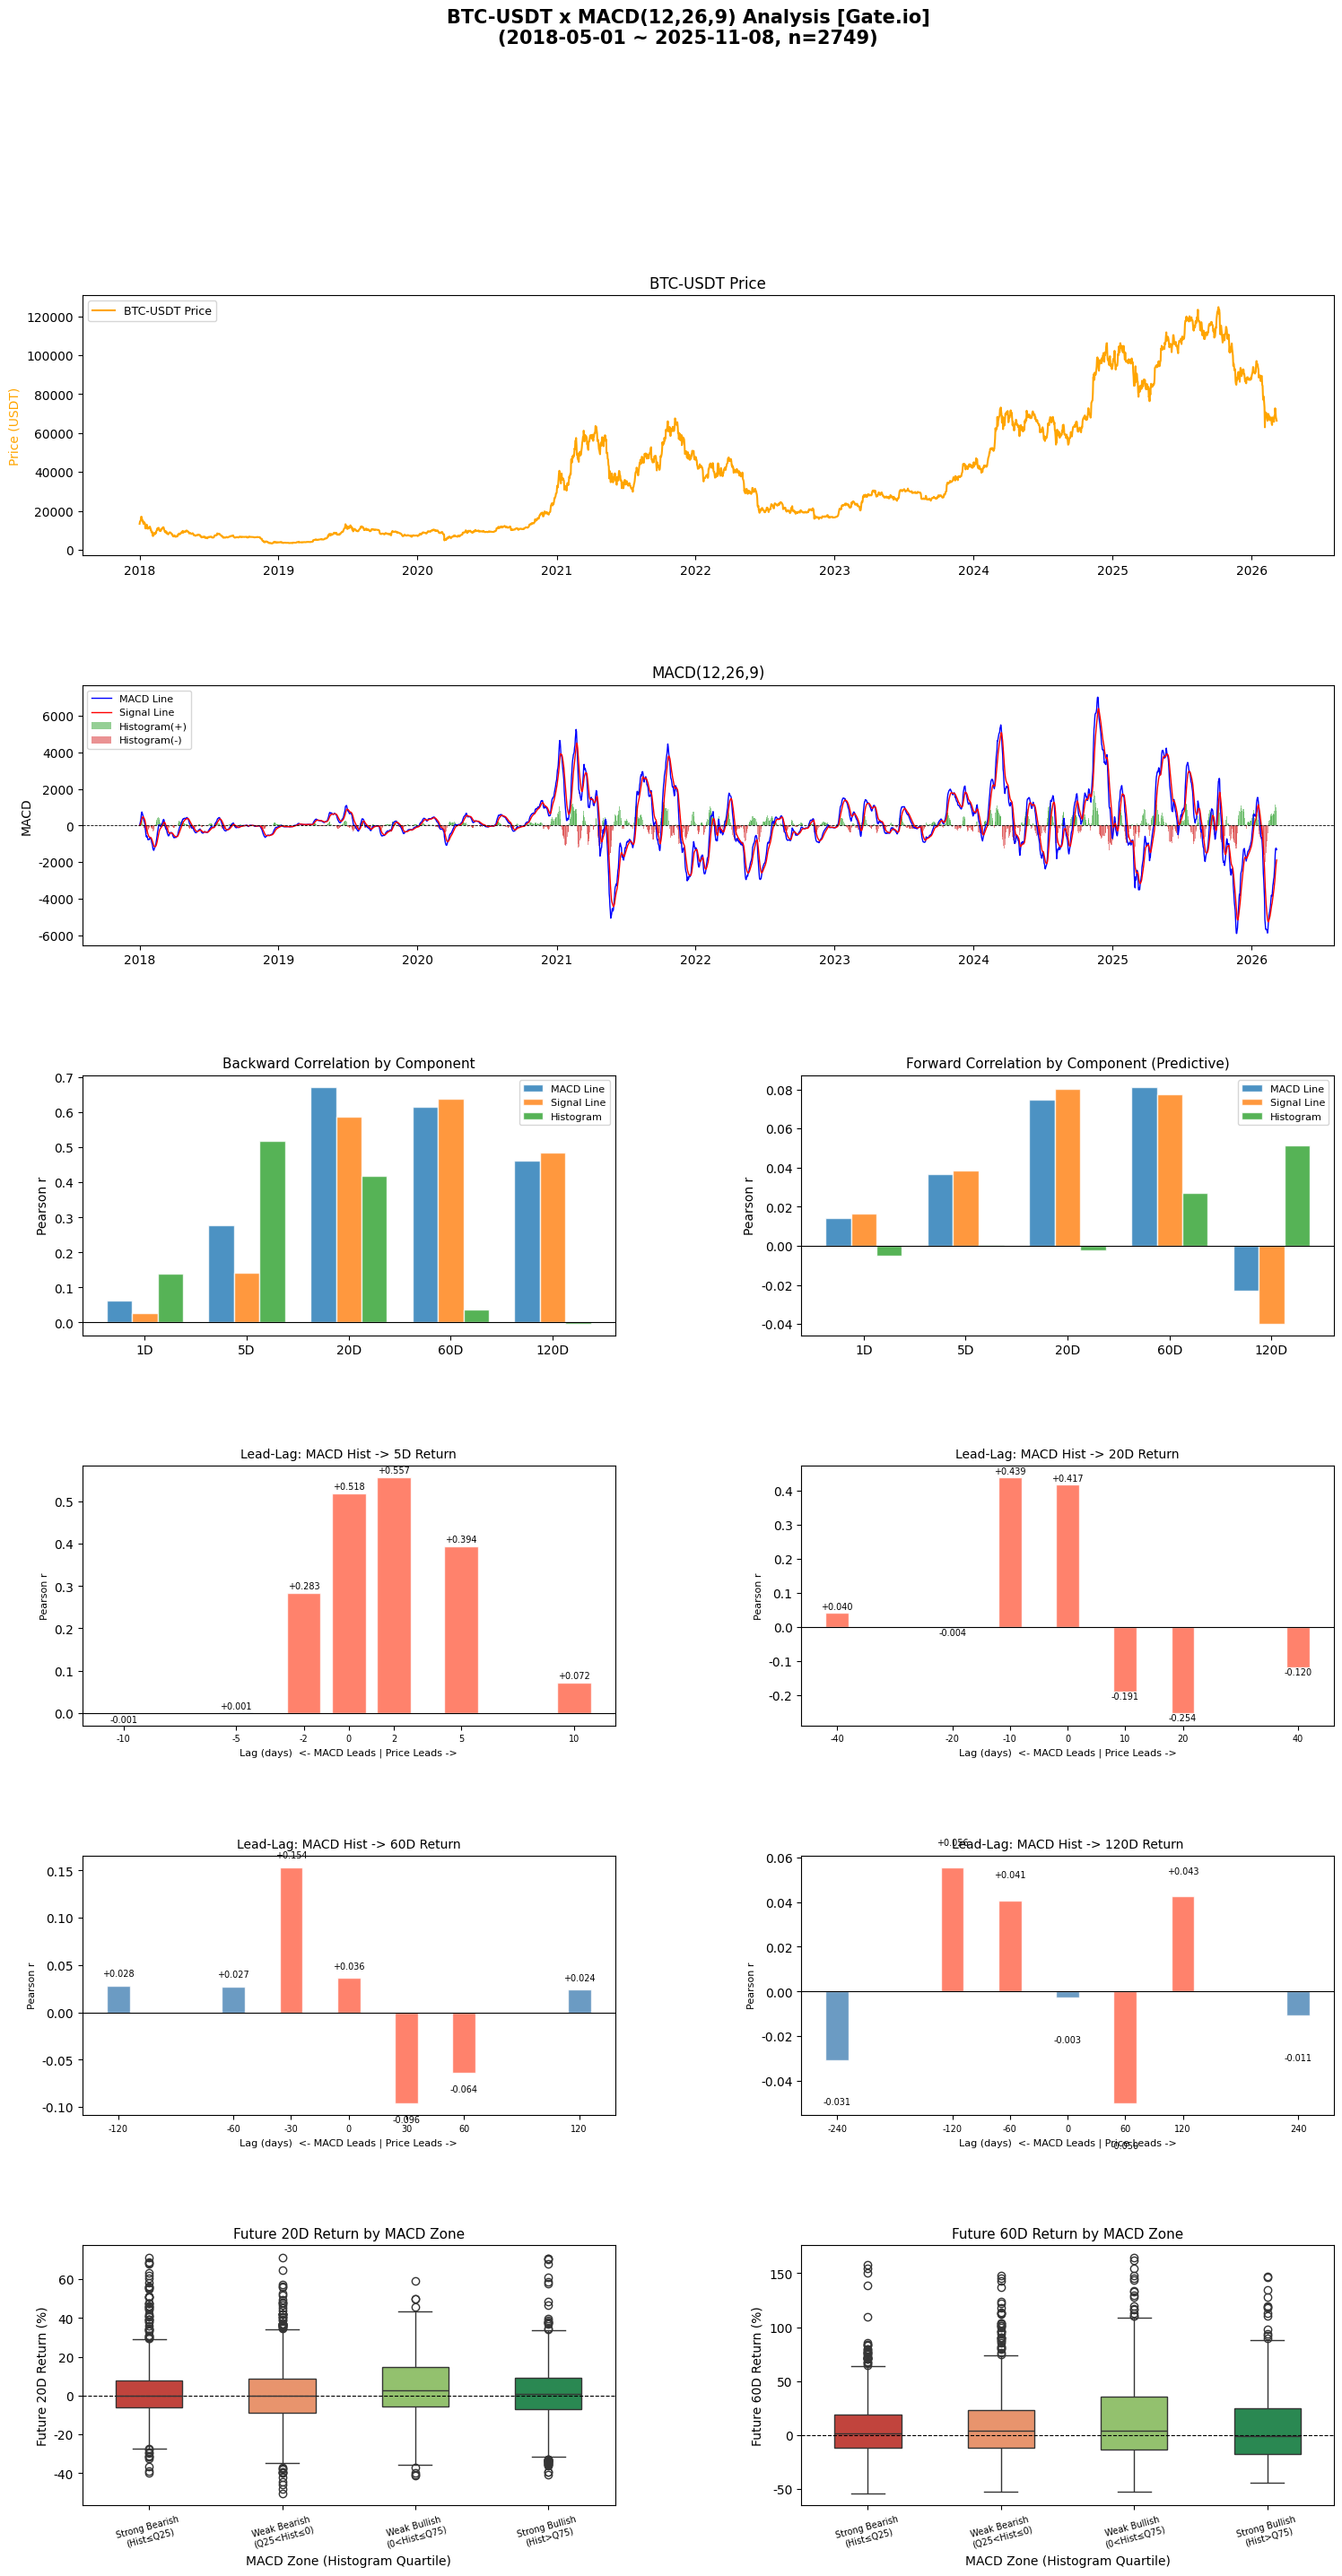


✅ Saved: macd_BTC-USDT_gateio_analysis.png


In [5]:
import ccxt
import pandas as pd
import requests
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from scipy import stats
import numpy as np
import warnings
import json
import requests as req
from google.colab import userdata

warnings.filterwarnings('ignore')
matplotlib.rcParams['font.family'] = 'DejaVu Sans'
matplotlib.rcParams['axes.unicode_minus'] = False

# =====================
# ⚙️ 설정값
# =====================
SYMBOL      = 'BTC/USDT'
START_DATE  = '2018-01-01'

# MACD 파라미터
MACD_FAST   = 12
MACD_SLOW   = 26
MACD_SIGNAL = 9

PAST_WINDOWS   = [1, 5, 20, 60, 120]
FUTURE_WINDOWS = [1, 5, 20, 60, 120]

# =====================
# 1. Gate.io OHLCV
# =====================
print(f"📥 Fetching {SYMBOL} OHLCV from Gate.io...")
exchange = ccxt.gateio({'enableRateLimit': True})

since_ms = exchange.parse8601(f'{START_DATE}T00:00:00Z') if START_DATE else exchange.parse8601('2015-01-01T00:00:00Z')

all_ohlcv = []
prev_last_ts = None

while True:
    try:
        batch = exchange.fetch_ohlcv(SYMBOL, timeframe='1d', since=since_ms, limit=1000)
    except Exception as e:
        print(f"   ⚠️ Error: {e}")
        break
    if not batch:
        break
    last_ts = batch[-1][0]
    if last_ts == prev_last_ts:
        break
    if all_ohlcv and batch[0][0] == all_ohlcv[-1][0]:
        batch = batch[1:]
    all_ohlcv += batch
    prev_last_ts = last_ts
    since_ms = last_ts + 86400000
    print(f"   Fetched {len(all_ohlcv)} candles... (last: {pd.to_datetime(last_ts, unit='ms').date()})")
    if len(batch) < 1000 or last_ts >= exchange.milliseconds():
        break

df_price = pd.DataFrame(all_ohlcv, columns=['timestamp','open','high','low','close','volume'])
df_price['date'] = pd.to_datetime(df_price['timestamp'], unit='ms').dt.date
df_price = df_price[['date','close']].drop_duplicates('date').reset_index(drop=True)
print(f"   Price available: {df_price['date'].min()} ~ {df_price['date'].max()} ({len(df_price)} days)")

# =====================
# 2. MACD 계산
# =====================
def calc_macd(series, fast=12, slow=26, signal=9):
    ema_fast   = series.ewm(span=fast,   adjust=False).mean()
    ema_slow   = series.ewm(span=slow,   adjust=False).mean()
    macd_line  = ema_fast - ema_slow
    signal_line = macd_line.ewm(span=signal, adjust=False).mean()
    histogram  = macd_line - signal_line
    return macd_line, signal_line, histogram

df_price['macd'], df_price['macd_signal'], df_price['macd_hist'] = calc_macd(
    df_price['close'], MACD_FAST, MACD_SLOW, MACD_SIGNAL
)
print(f"\n✅ MACD({MACD_FAST},{MACD_SLOW},{MACD_SIGNAL}) calculated")

# =====================
# 3. 수익률 계산
# =====================
df = df_price.copy()

for w in PAST_WINDOWS:
    df[f'return_{w}d'] = df['close'].pct_change(w) * 100

for w in FUTURE_WINDOWS:
    df[f'future_return_{w}d'] = (df['close'].shift(-w) / df['close'] - 1) * 100

coin_name = SYMBOL.replace('/', '-')

# =====================
# MACD 구간 라벨 (히스토그램 기준)
# =====================
def macd_zone_label(hist):
    """MACD 히스토그램 값으로 시장 국면 분류"""
    if hist > 0:
        return 'Bullish\n(Hist>0)'
    else:
        return 'Bearish\n(Hist<0)'

def macd_zone_detailed(hist, q25, q75):
    """사분위 기준 4구간 분류"""
    if hist <= q25:
        return 'Strong Bearish\n(Hist≤Q25)'
    elif hist <= 0:
        return 'Weak Bearish\n(Q25<Hist≤0)'
    elif hist <= q75:
        return 'Weak Bullish\n(0<Hist≤Q75)'
    else:
        return 'Strong Bullish\n(Hist>Q75)'

q25 = df['macd_hist'].quantile(0.25)
q75 = df['macd_hist'].quantile(0.75)

zone_order = [
    'Strong Bearish\n(Hist≤Q25)',
    'Weak Bearish\n(Q25<Hist≤0)',
    'Weak Bullish\n(0<Hist≤Q75)',
    'Strong Bullish\n(Hist>Q75)'
]
palette = ['#d73027', '#fc8d59', '#91cf60', '#1a9850']

df['macd_zone'] = df['macd_hist'].apply(lambda x: macd_zone_detailed(x, q25, q75))
df_clean = df.dropna().reset_index(drop=True)

print(f"✅ Analysis period: {df_clean['date'].min()} ~ {df_clean['date'].max()} ({len(df_clean)} days)\n")

# =====================
# 4. MACD 각 요소별 상관관계 (과거 수익률)
# =====================
macd_components = {
    'MACD Line': 'macd',
    'Signal Line': 'macd_signal',
    'Histogram': 'macd_hist'
}

print("=" * 80)
print(f"📊 [{coin_name}] MACD({MACD_FAST},{MACD_SLOW},{MACD_SIGNAL}) <-> Backward-Looking Return Correlation")
print("=" * 80)

corr_results_all = {}
for comp_name, comp_col in macd_components.items():
    print(f"\n  [{comp_name}]")
    print(f"  {'Window':<12} {'r':>8}  {'p-value':>10}  Result")
    print("  " + "-" * 60)
    comp_results = []
    for w in PAST_WINDOWS:
        col = f'return_{w}d'
        tmp = df[[comp_col, col]].dropna()
        r, p = stats.pearsonr(tmp[comp_col], tmp[col])
        sig = "✅ Significant" if p < 0.05 else "❌ Not Significant"
        comp_results.append({'window': w, 'r': r, 'p': p})
        print(f"  {str(w)+'D':<12} {r:>+8.4f}  {p:>10.4f}  {sig}")
    corr_results_all[comp_name] = comp_results

# 히스토그램 결과를 메인으로 사용
corr_results = corr_results_all['Histogram']

# =====================
# 5. MACD -> 미래 수익률 상관관계
# =====================
print("\n" + "=" * 80)
print(f"📊 [{coin_name}] MACD <-> Forward Return Correlation (Predictive Test)")
print("=" * 80)

future_corr_results_all = {}
for comp_name, comp_col in macd_components.items():
    print(f"\n  [{comp_name}]")
    print(f"  {'Window':<12} {'r':>8}  {'p-value':>10}  Result")
    print("  " + "-" * 60)
    comp_results = []
    for w in FUTURE_WINDOWS:
        col = f'future_return_{w}d'
        tmp = df[[comp_col, col]].dropna()
        r, p = stats.pearsonr(tmp[comp_col], tmp[col])
        sig = "✅ Significant" if p < 0.05 else "❌ Not Significant"
        comp_results.append({'window': w, 'r': r, 'p': p})
        print(f"  {str(w)+'D':<12} {r:>+8.4f}  {p:>10.4f}  {sig}")
    future_corr_results_all[comp_name] = comp_results

future_corr_results = future_corr_results_all['Histogram']

# =====================
# 6. Lead-Lag (MACD Histogram 기준)
# =====================
print("\n" + "=" * 80)
print(f"📊 [{coin_name}] Lead-Lag Analysis (MACD Histogram -> Returns)")
print("=" * 80)

LAG_WINDOWS = [1, 5, 20, 60, 120]
all_lag_results = {}
best_lag_summary = []

for w in LAG_WINDOWS:
    print(f"\n--- {w}D Return ---")
    print(f"{'Lag':>8}  {'r':>8}  {'p-value':>9}  {'Sig':>4}  Interpretation")
    print("-" * 70)

    max_lag = w * 2
    lags = sorted(set([-max_lag, -w, -max(1, w//2), 0, max(1, w//2), w, max_lag]))

    lag_results = []
    for lag in lags:
        col = f'return_{w}d'
        tmp = df[['macd_hist', col]].dropna().reset_index(drop=True)

        if lag < 0:
            x = tmp['macd_hist'].iloc[:lag].values
            y = tmp[col].iloc[-lag:].values
            direction = f"MACD leads by {abs(lag)}d"
        elif lag > 0:
            x = tmp['macd_hist'].iloc[lag:].values
            y = tmp[col].iloc[:-lag].values
            direction = f"Price leads by {lag}d"
        else:
            x = tmp['macd_hist'].values
            y = tmp[col].values
            direction = "Concurrent"

        r, p = stats.pearsonr(x, y)
        sig = "✅" if p < 0.05 else "  "
        lag_results.append({'lag': lag, 'r': r, 'p': p, 'direction': direction})
        print(f"{lag:>8}  {r:>+8.4f}  {p:>9.4f}  {sig:>4}  {direction}")

    df_lag = pd.DataFrame(lag_results)
    best = df_lag.loc[df_lag['r'].abs().idxmax()]
    print(f"📌 Max: lag={int(best['lag'])}d ({best['direction']}), r={best['r']:+.4f}")

    all_lag_results[w] = lag_results
    best_lag_summary.append({
        'window': w,
        'best_lag': int(best['lag']),
        'best_r': float(best['r']),
        'best_p': float(best['p']),
        'direction': best['direction']
    })

# =====================
# 7. MACD 구간별 미래 수익률
# =====================
print("\n" + "=" * 80)
print(f"📊 [{coin_name}] Future Return by MACD Zone (Histogram Quartiles)")
print("=" * 80)

zone_stats_all = {}
for w in FUTURE_WINDOWS:
    col = f'future_return_{w}d'
    tmp = df[['macd_zone', col]].dropna().copy()
    zone_stats = (
        tmp.groupby('macd_zone')[col]
        .agg(['count','mean','median','std'])
        .reindex(zone_order)
        .reset_index()
    )
    zone_stats_all[w] = zone_stats
    print(f"\n--- Future {w}D Return by MACD Zone ---")
    print(zone_stats.to_string(index=False))

# =====================
# 8. AI 해석
# =====================
print("\n" + "=" * 80)
print(f"🤖 [{coin_name}] AI Interpretation")
print("=" * 80)

GEMINI_API_KEY = userdata.get('GOOGLE_API_KEY')

analysis_data = {
    "coin": coin_name,
    "indicator": f"MACD({MACD_FAST},{MACD_SLOW},{MACD_SIGNAL})",
    "analysis_period": f"{df_clean['date'].min()} ~ {df_clean['date'].max()} ({len(df_clean)} days)",
    "backward_correlation_histogram": [
        {"window": f"{c['window']}D", "r": round(float(c['r']), 4), "p": round(float(c['p']), 4)}
        for c in corr_results
    ],
    "forward_correlation_histogram": [
        {"window": f"{c['window']}D", "r": round(float(c['r']), 4), "p": round(float(c['p']), 4)}
        for c in future_corr_results
    ],
    "lead_lag_best": [
        {"return_window": f"{s['window']}D", "best_lag_days": int(s['best_lag']),
         "r": round(float(s['best_r']), 4), "direction": s['direction']}
        for s in best_lag_summary
    ],
    "zone_future_return_mean": {
        f"{w}D": {
            row['macd_zone'].replace('\n', ' '): None if pd.isna(row['mean']) else round(float(row['mean']), 4)
            for _, row in zone_stats_all[w].iterrows()
        }
        for w in FUTURE_WINDOWS
    }
}

prompt = f"""
You are a quantitative finance analyst.
Interpret the relationship between MACD({MACD_FAST},{MACD_SLOW},{MACD_SIGNAL}) and {coin_name} price returns.

The MACD Histogram (= MACD Line - Signal Line) is the primary indicator used.
Positive histogram = bullish momentum, Negative = bearish momentum.

Analysis Data:
{json.dumps(analysis_data, indent=2)}

Please explain:
1. Backward-looking correlation — does MACD histogram reflect past price momentum well?
2. Forward-return (predictive) correlation — can MACD histogram predict future returns?
3. Lead-lag takeaway — does MACD lead or lag price?
4. MACD zone analysis — which zones (Strong Bearish / Weak Bearish / Weak Bullish / Strong Bullish) show the best/worst future returns? Any mean-reversion patterns?
5. One-line overall conclusion on MACD's usefulness as a signal

Be specific, data-driven, and reference actual r-values and lag values.
Write in English, 220-320 words.
"""

MODELS = [
    "gemini-2.5-flash-lite",
    "gemini-2.5-flash",
    "gemini-flash-latest",
    "gemini-2.5-pro",
]

text = None
if GEMINI_API_KEY:
    for model_name in MODELS:
        try:
            url = f"https://generativelanguage.googleapis.com/v1beta/models/{model_name}:generateContent?key={GEMINI_API_KEY}"
            resp = req.post(url, json={"contents": [{"parts": [{"text": prompt}]}]}, timeout=30)
            result = resp.json()
            if "candidates" in result:
                text = result["candidates"][0]["content"]["parts"][0]["text"]
                print(f"✅ Model used: {model_name}\n")
                print(text)
                break
            else:
                err_msg = result.get("error", {}).get("message", "Unknown error")
                print(f"⚠️ {model_name} failed: {err_msg.splitlines()[0]}")
        except Exception as e:
            print(f"⚠️ {model_name} error: {e}")

if text is None:
    print("\n⚠️ Gemini unavailable. Using rule-based interpretation.\n")
    backward_df = pd.DataFrame(corr_results)
    best_b = backward_df.loc[backward_df['r'].abs().idxmax()]
    forward_df_r = pd.DataFrame(future_corr_results)
    best_f = forward_df_r.loc[forward_df_r['r'].abs().idxmax()]
    lag_df = pd.DataFrame(best_lag_summary)
    print(f"Strongest backward correlation: {int(best_b['window'])}D (r={best_b['r']:+.4f})")
    print(f"Strongest forward correlation:  {int(best_f['window'])}D (r={best_f['r']:+.4f})")
    print(f"Price leads: {int((lag_df['best_lag']>0).sum())}  |  MACD leads: {int((lag_df['best_lag']<0).sum())}  |  Concurrent: {int((lag_df['best_lag']==0).sum())}")

# =====================
# 9. 시각화
# =====================
fig = plt.figure(figsize=(18, 32))
fig.suptitle(
    f'{coin_name} x MACD({MACD_FAST},{MACD_SLOW},{MACD_SIGNAL}) Analysis [Gate.io]\n'
    f'({df_clean["date"].min()} ~ {df_clean["date"].max()}, n={len(df_clean)})',
    fontsize=15, fontweight='bold'
)
gs = fig.add_gridspec(6, 2, hspace=0.50, wspace=0.35)

dates = pd.to_datetime(df['date'])

# ─────────────────────────────────────────────
# Chart 1: Price + MACD 전체 (상단 2행 span)
# ─────────────────────────────────────────────
ax_price = fig.add_subplot(gs[0, :])
ax_price.plot(dates, df['close'], color='orange', linewidth=1.5, label=f'{coin_name} Price')
ax_price.set_ylabel('Price (USDT)', color='orange')
ax_price.set_title(f'{coin_name} Price', fontsize=12)
ax_price.legend(loc='upper left', fontsize=9)

ax_macd = fig.add_subplot(gs[1, :], sharex=ax_price)
ax_macd.plot(dates, df['macd'],        color='blue',   linewidth=1.0, label='MACD Line')
ax_macd.plot(dates, df['macd_signal'], color='red',    linewidth=1.0, label='Signal Line')
# Histogram: 색상 구분
pos_mask = df['macd_hist'] >= 0
ax_macd.bar(dates[pos_mask],  df['macd_hist'][pos_mask],  color='#2ca02c', alpha=0.5, width=1.5, label='Histogram(+)')
ax_macd.bar(dates[~pos_mask], df['macd_hist'][~pos_mask], color='#d62728', alpha=0.5, width=1.5, label='Histogram(-)')
ax_macd.axhline(0, color='black', linewidth=0.6, linestyle='--')
ax_macd.set_ylabel('MACD')
ax_macd.set_title(f'MACD({MACD_FAST},{MACD_SLOW},{MACD_SIGNAL})', fontsize=12)
ax_macd.legend(loc='upper left', fontsize=8)

# ─────────────────────────────────────────────
# Chart 2: Backward Correlation (3 components)
# ─────────────────────────────────────────────
ax_c1 = fig.add_subplot(gs[2, 0])
x_pos = np.arange(len(PAST_WINDOWS))
width = 0.25
comp_colors = ['#1f77b4', '#ff7f0e', '#2ca02c']
for i, (comp_name, _) in enumerate(macd_components.items()):
    r_vals = [c['r'] for c in corr_results_all[comp_name]]
    ax_c1.bar(x_pos + i*width, r_vals, width=width, color=comp_colors[i],
              alpha=0.8, label=comp_name, edgecolor='white')
ax_c1.axhline(0, color='black', linewidth=0.8)
ax_c1.set_title('Backward Correlation by Component', fontsize=11)
ax_c1.set_ylabel('Pearson r')
ax_c1.set_xticks(x_pos + width)
ax_c1.set_xticklabels([f'{w}D' for w in PAST_WINDOWS])
ax_c1.legend(fontsize=8)

# ─────────────────────────────────────────────
# Chart 3: Forward Correlation (3 components)
# ─────────────────────────────────────────────
ax_c2 = fig.add_subplot(gs[2, 1])
for i, (comp_name, _) in enumerate(macd_components.items()):
    r_vals = [c['r'] for c in future_corr_results_all[comp_name]]
    ax_c2.bar(x_pos + i*width, r_vals, width=width, color=comp_colors[i],
              alpha=0.8, label=comp_name, edgecolor='white')
ax_c2.axhline(0, color='black', linewidth=0.8)
ax_c2.set_title('Forward Correlation by Component (Predictive)', fontsize=11)
ax_c2.set_ylabel('Pearson r')
ax_c2.set_xticks(x_pos + width)
ax_c2.set_xticklabels([f'{w}D' for w in FUTURE_WINDOWS])
ax_c2.legend(fontsize=8)

# ─────────────────────────────────────────────
# Chart 4~7: Lead-Lag (MACD Histogram)
# ─────────────────────────────────────────────
positions = [(3,0),(3,1),(4,0),(4,1)]
for idx, w in enumerate([5, 20, 60, 120]):
    row, col = positions[idx]
    ax = fig.add_subplot(gs[row, col])
    df_lag = pd.DataFrame(all_lag_results[w])
    lag_colors = ['tomato' if p < 0.05 else 'steelblue' for p in df_lag['p']]
    bar_width = max(df_lag['lag'].diff().dropna().abs().min() * 0.4, 1.5)
    ax.bar(df_lag['lag'], df_lag['r'], width=bar_width, color=lag_colors, alpha=0.8, edgecolor='white')
    ax.axhline(0, color='black', linewidth=0.8)
    ax.set_title(f'Lead-Lag: MACD Hist -> {w}D Return', fontsize=10)
    ax.set_xlabel('Lag (days)  <- MACD Leads | Price Leads ->', fontsize=8)
    ax.set_ylabel('Pearson r', fontsize=8)
    ax.set_xticks(df_lag['lag'].tolist())
    ax.tick_params(axis='x', labelsize=7)
    for _, row_data in df_lag.iterrows():
        ax.text(row_data['lag'], row_data['r'] + (0.01 if row_data['r'] >= 0 else -0.02),
                f"{row_data['r']:+.3f}", ha='center', fontsize=7)

# ─────────────────────────────────────────────
# Chart 8: Zone vs future 20D
# ─────────────────────────────────────────────
ax_z1 = fig.add_subplot(gs[5, 0])
tmp20 = df[['macd_zone','future_return_20d']].dropna().copy()
sns.boxplot(data=tmp20, x='macd_zone', y='future_return_20d',
            order=zone_order, palette=palette, ax=ax_z1, width=0.5)
ax_z1.axhline(0, color='black', linewidth=0.8, linestyle='--')
ax_z1.set_title('Future 20D Return by MACD Zone', fontsize=11)
ax_z1.set_xlabel('MACD Zone (Histogram Quartile)')
ax_z1.set_ylabel('Future 20D Return (%)')
ax_z1.tick_params(axis='x', rotation=15, labelsize=7)

# ─────────────────────────────────────────────
# Chart 9: Zone vs future 60D
# ─────────────────────────────────────────────
ax_z2 = fig.add_subplot(gs[5, 1])
tmp60 = df[['macd_zone','future_return_60d']].dropna().copy()
sns.boxplot(data=tmp60, x='macd_zone', y='future_return_60d',
            order=zone_order, palette=palette, ax=ax_z2, width=0.5)
ax_z2.axhline(0, color='black', linewidth=0.8, linestyle='--')
ax_z2.set_title('Future 60D Return by MACD Zone', fontsize=11)
ax_z2.set_xlabel('MACD Zone (Histogram Quartile)')
ax_z2.set_ylabel('Future 60D Return (%)')
ax_z2.tick_params(axis='x', rotation=15, labelsize=7)

plt.savefig(f'macd_{coin_name}_gateio_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"\n✅ Saved: macd_{coin_name}_gateio_analysis.png")